# 02 External Context Review: Weather, Events & Holidays

**NYC Taxi Operational Friction**  
**Portfolio Project**  
**Author:** Vinicius Miozzo  
**Date:** April 2026

---

## Objective

Create a clean daily context dataset that captures broad factors which may affect taxi activity across time, including:

- weather  
- permitted-event intensity  
- holiday effects  

This notebook is **not** estimating causal effects and is not yet producing a final mobility-friction score.

---

## Setup & Imports


In [19]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import holidays
import urllib.parse  
import requests

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.2f}".format)

# Project paths
from nyc_mobility_friction.paths import get_project_paths
paths = get_project_paths()

# Create external data folder if needed
external_dir = paths.raw / "external"
external_dir.mkdir(parents=True, exist_ok=True)

print("External data folder ready:", external_dir)

# Project paths
from nyc_mobility_friction.paths import get_project_paths
paths = get_project_paths()

external_dir = paths.raw / "external"
external_dir.mkdir(parents=True, exist_ok=True)

print("External data folder ready:", external_dir)

External data folder ready: /home/vinicius/home/vinicius/data_science_portifolio/nyc-mobility-friction/data/raw/external
External data folder ready: /home/vinicius/home/vinicius/data_science_portifolio/nyc-mobility-friction/data/raw/external


In [20]:
STUDY_START = pd.Timestamp("2025-01-01")
STUDY_END   = pd.Timestamp("2025-04-01")   # exclusive

print("Study window:", STUDY_START.date(), "to", (STUDY_END - pd.Timedelta(days=1)))

Study window: 2025-01-01 to 2025-03-31 00:00:00


## Study window

All source data in this notebook is filtered to the Jan-Mar 2025 study window.

The taxi data originally contained a small number of out-of-window timestamps, so a strict pickup-date filter is applied before any aggregation.

---

## 1. Load Taxi Data (3 Months) – Reference



In [21]:
taxi_dir = paths.raw / "taxi"
taxi_files = sorted(taxi_dir.glob("yellow_tripdata_2025-*.parquet"))

taxi = pd.concat([pd.read_parquet(f) for f in taxi_files], ignore_index=True)

taxi = taxi.rename(columns=str.lower).rename(columns=lambda x: x.replace(" ", "_"))
taxi["pickup_datetime"] = pd.to_datetime(taxi["tpep_pickup_datetime"], errors="coerce")
taxi["dropoff_datetime"] = pd.to_datetime(taxi["tpep_dropoff_datetime"], errors="coerce")

# Strict study window filter
taxi = taxi[
    taxi["pickup_datetime"].notna() &
    (taxi["pickup_datetime"] >= STUDY_START) &
    (taxi["pickup_datetime"] < STUDY_END)
].copy()

taxi["pickup_date"] = taxi["pickup_datetime"].dt.date

print(f"Loaded {len(taxi):,} taxi trips after study-window filter")
print("Date range:", taxi["pickup_datetime"].min(), "→", taxi["pickup_datetime"].max())

Loaded 11,198,001 taxi trips after study-window filter
Date range: 2025-01-01 00:00:00 → 2025-03-31 23:59:59


----

## 2. Load Taxi Zone Lookup (Official TLC)



In [23]:
zone_url = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"
zones = pd.read_csv(zone_url)

print(f"Loaded {len(zones)} taxi zones")
display(zones.head())
print("\nBorough distribution:")
print(zones["Borough"].value_counts())

Loaded 265 taxi zones


,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone



Borough distribution:
Borough
Queens           69
Manhattan        69
Brooklyn         61
Bronx            43
Staten Island    20
EWR               1
Unknown           1
Name: count, dtype: int64


In [6]:
print("Taxi rows after study-window filter:", len(taxi))
print("Taxi date range:", taxi["pickup_datetime"].min(), "to", taxi["pickup_datetime"].max())

Taxi rows after study-window filter: 11198001
Taxi date range: 2025-01-01 00:00:00 to 2025-03-31 23:59:59


---

## 3. Load NYC Permitted Events (Historical)

Direct download from NYC Open Data (covers Jan–Mar 2025).



In [25]:
events_path = external_dir / "nyc_permitted_events_jan_mar_2025.csv"

try:
    from sodapy import Socrata
    print("Using official Socrata client...")
    client = Socrata("data.cityofnewyork.us", None)
    
    where_clause = f"start_date_time >= '2025-01-01' AND start_date_time <= '2025-03-31'"
    
    results = []
    offset = 0
    limit = 1000
    while True:
        batch = client.get("bkfu-528j", where=where_clause, limit=limit, offset=offset)
        if not batch:
            break
        results.extend(batch)
        offset += limit
        print(f"   Fetched {len(results):,} events...")
    
    events = pd.DataFrame.from_records(results)
    events.to_csv(events_path, index=False)
    print(f"✅ Loaded {len(events):,} events via sodapy")
    
except Exception as e:
    print(f"⚠️ Socrata error: {e}")
    if events_path.exists():
        events = pd.read_csv(events_path)
        print(f"✅ Loaded cached file ({len(events):,} rows)")
    else:
        events = pd.DataFrame()

# Clean events
if len(events) > 0:
    events["start_date_time"] = pd.to_datetime(events["start_date_time"], errors="coerce")
    events["event_date"] = events["start_date_time"].dt.date
    daily_events = events.groupby("event_date").size().reset_index(name="citywide_permitted_event_count")
    print(f"Days with at least one permitted event: {len(daily_events)}")

Using official Socrata client...
   Fetched 1,000 events...
   Fetched 2,000 events...
   Fetched 3,000 events...
   Fetched 4,000 events...
   Fetched 5,000 events...
   Fetched 6,000 events...
   Fetched 7,000 events...
   Fetched 8,000 events...
   Fetched 9,000 events...
   Fetched 10,000 events...
   Fetched 11,000 events...
   Fetched 12,000 events...
   Fetched 13,000 events...
   Fetched 14,000 events...
   Fetched 15,000 events...
   Fetched 16,000 events...
   Fetched 17,000 events...
   Fetched 18,000 events...
   Fetched 19,000 events...
   Fetched 20,000 events...
   Fetched 21,000 events...
   Fetched 22,000 events...
   Fetched 23,000 events...
   Fetched 24,000 events...
   Fetched 25,000 events...
   Fetched 26,000 events...
   Fetched 27,000 events...
   Fetched 28,000 events...
   Fetched 29,000 events...
   Fetched 30,000 events...
   Fetched 31,000 events...
   Fetched 32,000 events...
   Fetched 33,000 events...
   Fetched 34,000 events...
   Fetched 35,000 events

In [8]:
print("Permitted events rows:", len(events))
print("Event date range:", events["start_date_time"].min(), "to", events["start_date_time"].max())

Permitted events rows: 223866
Event date range: 2025-01-01 00:00:00 to 2025-03-31 00:00:00


---

## 4. Weather Data (Jan–Mar 2025)



In [11]:
def fetch_weather(start_date: str, end_date: str) -> pd.DataFrame:
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": 40.78,
        "longitude": -73.97,
        "start_date": start_date.strftime("%Y-%m-%d"),
        "end_date": end_date.strftime("%Y-%m-%d"),
        "daily": ",".join([
            "weather_code",
            "temperature_2m_max",
            "temperature_2m_min",
            "precipitation_sum",
            "snowfall_sum",
            "precipitation_hours",
            "wind_speed_10m_max",
        ]),
        "temperature_unit": "fahrenheit",
        "wind_speed_unit": "mph",
        "precipitation_unit": "inch",
        "timezone": "America/New_York",
    }

    r = requests.get(url, params=params, timeout=60)
    r.raise_for_status()
    data = r.json()["daily"]

    weather = pd.DataFrame(data)
    weather["date"] = pd.to_datetime(weather["time"])
    weather = weather.drop(columns=["time"])
    weather["temp_avg_f"] = (
        weather["temperature_2m_max"] + weather["temperature_2m_min"]
    ) / 2
    weather["has_precip"] = weather["precipitation_sum"] > 0
    weather["has_snow"] = weather["snowfall_sum"] > 0
    return weather

weather = fetch_weather(STUDY_START, STUDY_END)
weather.head()

,weather_code,temperature_2m_max,temperature_2m_min,precipitation_sum,snowfall_sum,precipitation_hours,wind_speed_10m_max,date,temp_avg_f,has_precip,has_snow
0,63,51.70,38.80,0.19,0.00,4.00,14.40,2025-01-01,45.25,True,False
1,3,41.60,32.90,0.00,0.00,0.00,16.00,2025-01-02,37.25,False,False
2,3,37.80,28.90,0.00,0.00,0.00,11.10,2025-01-03,33.35,False,False
3,3,31.80,27.70,0.00,0.00,0.00,15.70,2025-01-04,29.75,False,False
4,3,32.50,25.70,0.00,0.00,0.00,12.00,2025-01-05,29.10,False,False


In [12]:
print("Weather rows:", len(weather))
print("Weather date range:", weather["date"].min(), "to", weather["date"].max())

Weather rows: 91
Weather date range: 2025-01-01 00:00:00 to 2025-04-01 00:00:00


---

## 5. Holidays (US Federal + NYC Observances)



In [13]:
us_holidays = holidays.US(years=[2025], observed=True)

holidays_df = pd.DataFrame({
    "date": pd.date_range(STUDY_START, STUDY_END, freq="D")
})
holidays_df["holiday_name"] = holidays_df["date"].map(lambda d: us_holidays.get(d.date()))
holidays_df["is_holiday"] = holidays_df["holiday_name"].notna()

holidays_df[holidays_df["is_holiday"]]

,date,holiday_name,is_holiday
0,2025-01-01,New Year's Day,True
19,2025-01-20,Martin Luther King Jr. Day,True
47,2025-02-17,Washington's Birthday,True


In [14]:
print("Holiday rows:", len(holidays_df))
print("Holiday dates:", holidays_df.loc[holidays_df["is_holiday"], "date"].dt.date.tolist())

Holiday rows: 91
Holiday dates: [datetime.date(2025, 1, 1), datetime.date(2025, 1, 20), datetime.date(2025, 2, 17)]


---
## 6. Daily context table

The goal of this notebook is to create one clean daily table that can later be merged into zone-day taxi analysis.

This table contains:
- daily taxi volume for context
- citywide permitted-event intensity
- citywide weather
- holiday flags

In [28]:
# Daily taxi volume (for context)
daily_taxi = taxi.groupby("pickup_date").size().reset_index(name="trip_count")

daily_events.event_date = pd.to_datetime(daily_events.event_date)
holidays_df.date = pd.to_datetime(holidays_df.date)

# Merge all context
daily_context = daily_taxi.copy()
daily_context = daily_context.merge(daily_events, left_on="pickup_date", right_on="event_date", how="left")
daily_context = daily_context.merge(weather, left_on="pickup_date", right_on="date", how="left").drop(columns="date")
daily_context = daily_context.merge(holidays_df, left_on="pickup_date", right_on="date", how="left").drop(columns="date")

daily_context = daily_context.rename(columns={"pickup_date": "date"})
daily_context["has_permitted_event_day"] = daily_context["citywide_permitted_event_count"].fillna(0) > 0
daily_context["has_holiday"] = daily_context["holiday_name"].notna()
daily_context = daily_context.fillna(0)

print("Daily Context Preview (first 10 days):")
display(daily_context.head(15))

# Quick stats
print(f"\nDays with precipitation: {(daily_context['has_precip']).sum()}")
print(f"Days with snow: {(daily_context['has_snow']).sum()}")
print(f"Days with major events: {daily_context['has_permitted_event_day'].sum()}")

Daily Context Preview (first 10 days):


,date,trip_count,event_date,citywide_permitted_event_count,weather_code,temperature_2m_max,temperature_2m_min,precipitation_sum,snowfall_sum,precipitation_hours,wind_speed_10m_max,temp_avg_f,has_precip,has_snow,holiday_name,is_holiday,has_permitted_event_day,has_holiday
0,2025-01-01,90188,2025-01-01,671,63,51.70,38.80,0.19,0.00,4.00,14.40,45.25,True,False,New Year's Day,True,True,True
1,2025-01-02,84832,2025-01-02,640,3,41.60,32.90,0.00,0.00,0.00,16.00,37.25,False,False,0,False,True,False
2,2025-01-03,91250,2025-01-03,588,3,37.80,28.90,0.00,0.00,0.00,11.10,33.35,False,False,0,False,True,False
3,2025-01-04,97804,2025-01-04,1159,3,31.80,27.70,0.00,0.00,0.00,15.70,29.75,False,False,0,False,True,False
4,2025-01-05,79624,2025-01-05,1644,3,32.50,25.70,0.00,0.00,0.00,12.00,29.10,False,False,0,False,True,False
5,2025-01-06,80126,2025-01-06,722,73,29.30,23.70,0.06,0.44,7.00,11.30,26.50,True,True,0,False,True,False
6,2025-01-07,100643,2025-01-07,742,3,26.90,16.60,0.00,0.00,0.00,19.40,21.75,False,False,0,False,True,False
7,2025-01-08,113897,2025-01-08,684,3,27.70,20.10,0.00,0.00,0.00,16.60,23.90,False,False,0,False,True,False
8,2025-01-09,119285,2025-01-09,670,3,28.90,20.20,0.00,0.00,0.00,19.30,24.55,False,False,0,False,True,False
9,2025-01-10,111494,2025-01-10,594,3,37.90,25.40,0.00,0.00,0.00,14.60,31.65,False,False,0,False,True,False



Days with precipitation: 37
Days with snow: 16
Days with major events: 90


---

## 7. Sanity plots

These plots are intended as basic checks that the merged daily context table behaves as expected. They are not formal inference.

Plotting...


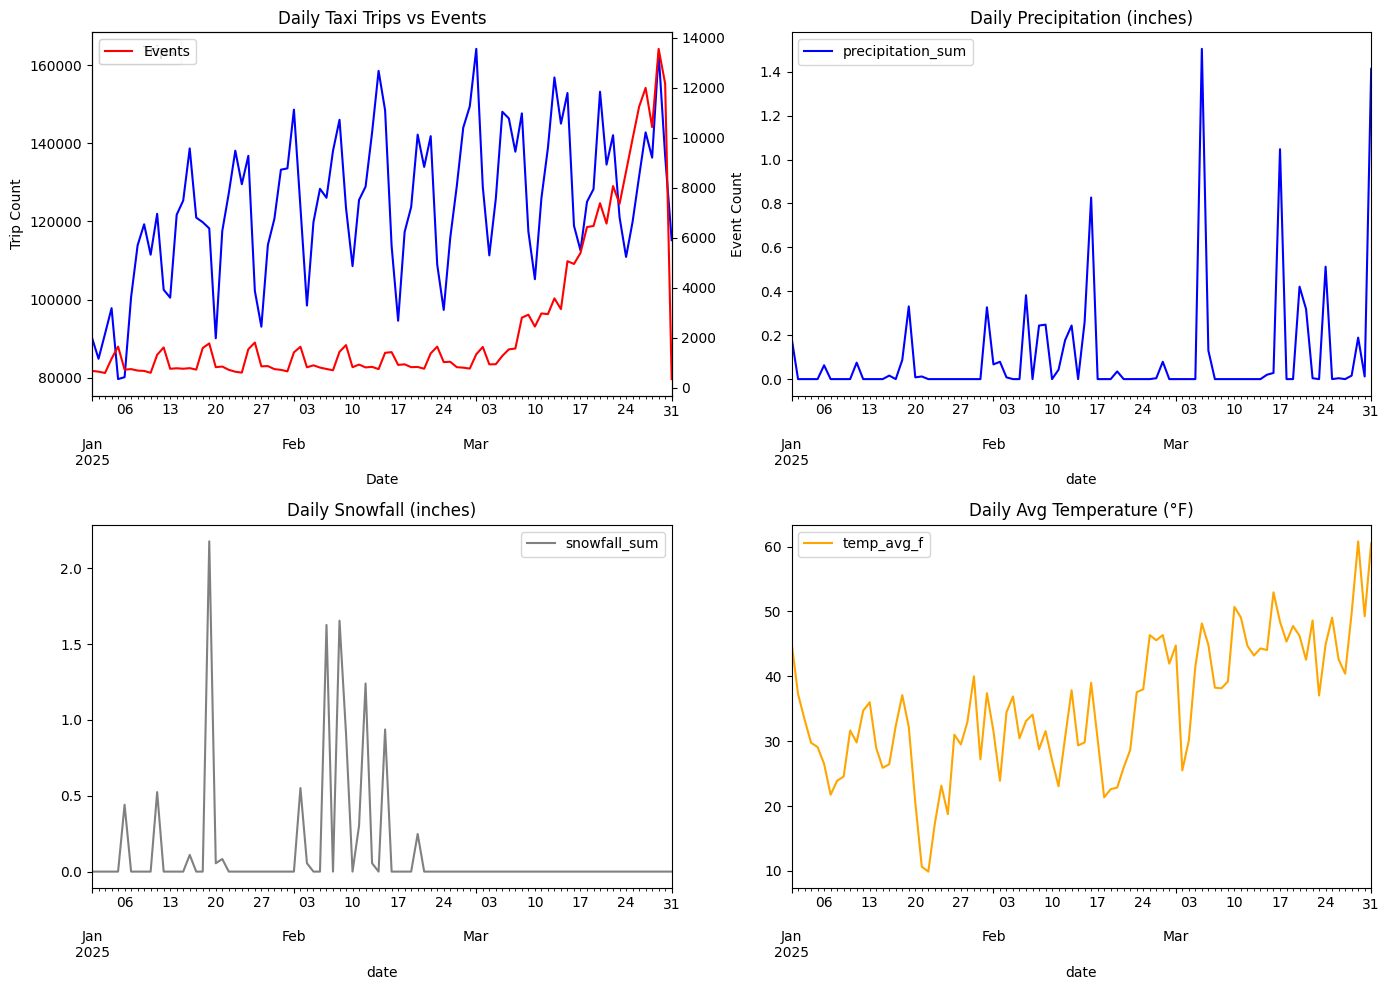

In [30]:
print("Plotting...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax1 = axes[0,0]
daily_context.plot(x="date", y="trip_count", ax=ax1, label="Trips", color="blue")
ax1.set_title("Daily Taxi Trips vs Events")
ax1.set_xlabel("Date")
ax1.set_ylabel("Trip Count")

if "citywide_permitted_event_count" in daily_context.columns:
    ax1_twin = ax1.twinx()
    daily_context.plot(x="date", y="citywide_permitted_event_count", ax=ax1_twin, label="Events", color="red")
    ax1_twin.set_ylabel("Event Count")

daily_context.plot(x="date", y="precipitation_sum", ax=axes[0,1], color="blue", title="Daily Precipitation (inches)")
daily_context.plot(x="date", y="snowfall_sum", ax=axes[1,0], color="gray", title="Daily Snowfall (inches)")
daily_context.plot(x="date", y="temp_avg_f", ax=axes[1,1], color="orange", title="Daily Avg Temperature (°F)")

plt.tight_layout()
plt.show()

## What this notebook established

This notebook successfully produced a clean daily context table for Jan–Mar 2025.Main takeaways:

- Taxi activity can now be reviewed against broad daily context variables.
- Weather and holidays are clean citywide daily features.
- Permitted events are represented as a coarse citywide daily signal (good enough for prototype).
- Later zone-level work may benefit from more localized event features, but this table is sufficient for early context review.

Next notebook (03_zone_level_aggregation.ipynb) will merge this daily context with zone-day taxi aggregates and compute the first friction score.

